Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
sns.set_palette("pastel")

# Tạo thư mục lưu biểu đồ nếu chưa tồn tại
os.makedirs("eda_chart", exist_ok=True)

df = pd.read_parquet("flights_2021_2025.parquet")

delay_cols = [
    'CARRIER_DELAY',
    'WEATHER_DELAY',
    'NAS_DELAY',
    'SECURITY_DELAY',
    'LATE_AIRCRAFT_DELAY'
]

# mapping tên tiếng Việt
name_causes = {
    'CARRIER_DELAY': 'Hãng hàng không',
    'WEATHER_DELAY': 'Thời tiết',
    'NAS_DELAY': 'Hệ thống NAS',
    'SECURITY_DELAY': 'An ninh',
    'LATE_AIRCRAFT_DELAY': 'Máy bay đến trễ'
}

df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
df['YEAR'] = df['FL_DATE'].dt.year

1. Tổng quan nguyên nhân trễ

In [8]:
delay_stats = pd.DataFrame({
    "Số chuyến bị trễ": (df[delay_cols] > 0).sum(),
    "Tổng phút trễ": df[delay_cols].sum(),
    "Trễ trung bình": df[delay_cols].mean()
})
delay_stats.index = delay_stats.index.map(name_causes)
delay_stats = delay_stats.sort_values(by="Tổng phút trễ", ascending=False)
display(delay_stats)

,Số chuyến bị trễ,Tổng phút trễ,Trễ trung bình
Hãng hàng không,259763,12459881.0,26.327438
Máy bay đến trễ,211884,11879809.0,25.101759
Hệ thống NAS,237204,6361917.0,13.442582
Thời tiết,34329,2747010.0,5.804368
An ninh,2730,70240.0,0.148415


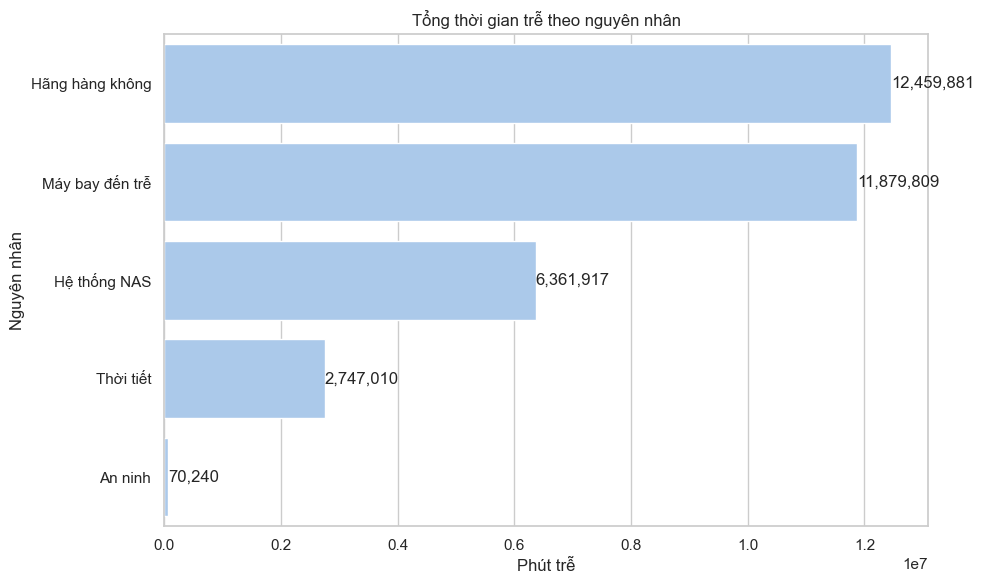

In [11]:
plt.figure(figsize=(10,6))
ax = sns.barplot(
    x=delay_stats["Tổng phút trễ"],
    y=delay_stats.index
)

for i, v in enumerate(delay_stats["Tổng phút trễ"]):
    ax.text(v, i, f"{v:,.0f}", va='center')

plt.title("Tổng thời gian trễ theo nguyên nhân")
plt.xlabel("Phút trễ")
plt.ylabel("Nguyên nhân")

plt.tight_layout()
plt.savefig("eda_chart/nguyen_nhan_gay_tre_lau_nhat.png")
plt.show()

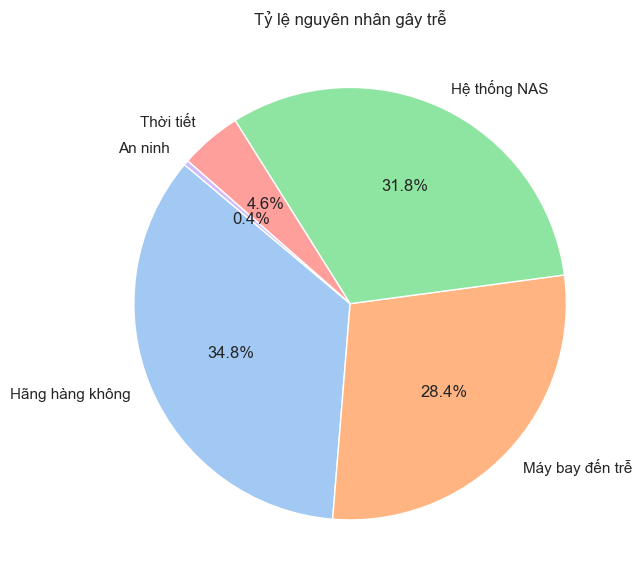

In [12]:
plt.figure(figsize=(10,6))

plt.pie(delay_stats["Số chuyến bị trễ"], labels=delay_stats.index, autopct='%1.1f%%', startangle=140)

plt.title("Tỷ lệ nguyên nhân gây trễ")
plt.tight_layout()
plt.savefig("eda_chart/ty_le_nguyen_nhan_gay_tre.png")
plt.show()

2. Phân tích theo thời gian

2.1. Theo năm

In [14]:
delay_yearly = df.groupby('YEAR')['ARR_DELAY'].mean().reset_index()
delay_yearly.columns = ['Năm', 'Trễ trung bình']

display(delay_yearly)

,Năm,Trễ trung bình
0,2021,-5.260106
1,2022,3.981086
2,2023,7.776393
3,2024,10.352299
4,2025,3.756614


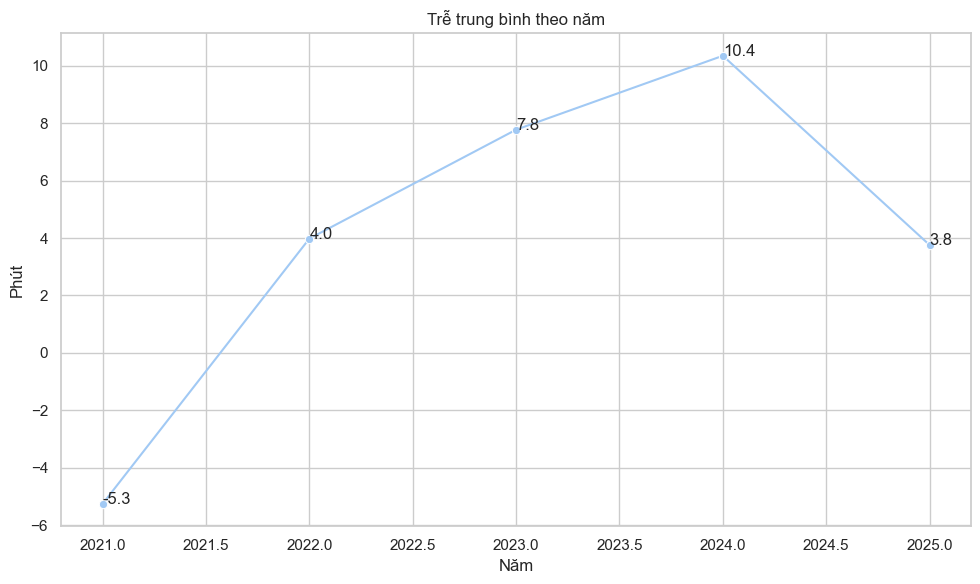

In [15]:
plt.figure(figsize=(10,6))
ax = sns.lineplot(data=delay_yearly, x='Năm', y='Trễ trung bình', marker='o')

for i, row in delay_yearly.iterrows():
    ax.text(row['Năm'], row['Trễ trung bình'], f"{row['Trễ trung bình']:.1f}")

plt.title("Trễ trung bình theo năm")
plt.tight_layout()
plt.ylabel("Phút")
plt.savefig("eda_chart/tre_theo_nam.png")
plt.show()

Nguyên nhân trễ theo năm

In [24]:
delay_causes_yearly = df.groupby('YEAR')[delay_cols].mean()
delay_causes_yearly.columns = [name_causes[col] for col in delay_causes_yearly.columns]

delay_causes_yearly = delay_causes_yearly.reset_index()

df_melted = delay_causes_yearly.melt(id_vars='YEAR', var_name='Nguyên nhân', value_name='Trễ trung bình')

display(df_melted)

,YEAR,Nguyên nhân,Trễ trung bình
0,2021,Hãng hàng không,26.877977
1,2022,Hãng hàng không,31.296038
2,2023,Hãng hàng không,24.509344
3,2024,Hãng hàng không,24.613653
4,2025,Hãng hàng không,25.587343
5,2021,Thời tiết,6.531163
6,2022,Thời tiết,4.097556
7,2023,Thời tiết,4.383967
8,2024,Thời tiết,7.747488
9,2025,Thời tiết,6.419770


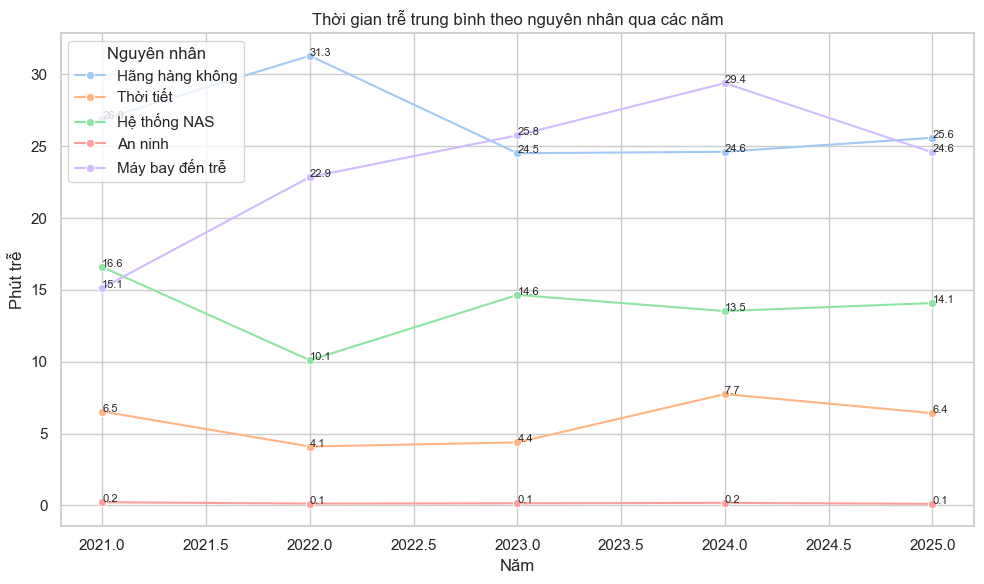

In [25]:
plt.figure(figsize=(10,6))

ax = sns.lineplot(
    data=df_melted,
    x='YEAR',
    y='Trễ trung bình',
    hue='Nguyên nhân',
    marker='o'
)

# hiển thị giá trị trên từng điểm
for line in ax.lines:
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        ax.text(x, y, f"{y:.1f}", fontsize=8)

plt.title("Thời gian trễ trung bình theo nguyên nhân qua các năm")
plt.xlabel("Năm")
plt.ylabel("Phút trễ")
plt.legend(title="Nguyên nhân")

plt.tight_layout()
plt.savefig("eda_chart/tre_theo_nguyen_nhan_va_nam.png")
plt.show()

2.2. Theo ngày trong tuần

In [17]:
mapping_days = {
    0: 'Thứ 2',
    1: 'Thứ 3',
    2: 'Thứ 4',
    3: 'Thứ 5',
    4: 'Thứ 6',
    5: 'Thứ 7',
    6: 'Chủ nhật'
}

delay_by_day = df.groupby('DAY_OF_WEEK')['ARR_DELAY'].mean().reset_index()
delay_by_day['DAY_OF_WEEK'] = delay_by_day['DAY_OF_WEEK'].map(mapping_days)
delay_by_day.columns = ['Ngày trong tuần', 'Trễ trung bình']

display(delay_by_day)

,Ngày trong tuần,Trễ trung bình
0,Thứ 2,7.470204
1,Thứ 3,4.232875
2,Thứ 4,3.495474
3,Thứ 5,1.799488
4,Thứ 6,4.793705
5,Thứ 7,3.561563
6,Chủ nhật,7.428217


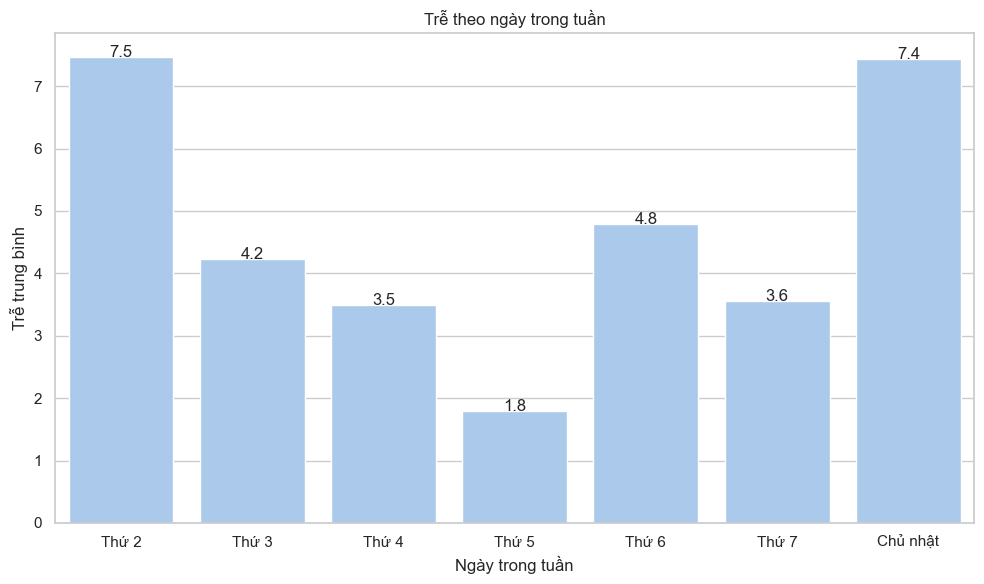

In [19]:
plt.figure(figsize=(10,6))
ax = sns.barplot(data=delay_by_day, x='Ngày trong tuần', y='Trễ trung bình')

for i, row in delay_by_day.iterrows():
    ax.text(i, row['Trễ trung bình'], f"{row['Trễ trung bình']:.1f}", ha='center')

plt.title("Trễ theo ngày trong tuần")
plt.tight_layout()
plt.savefig("eda_chart/tre_theo_ngay.png")
plt.show()

Trễ theo ngày trong tuần và theo nguyên nhân

2.3. Theo giờ

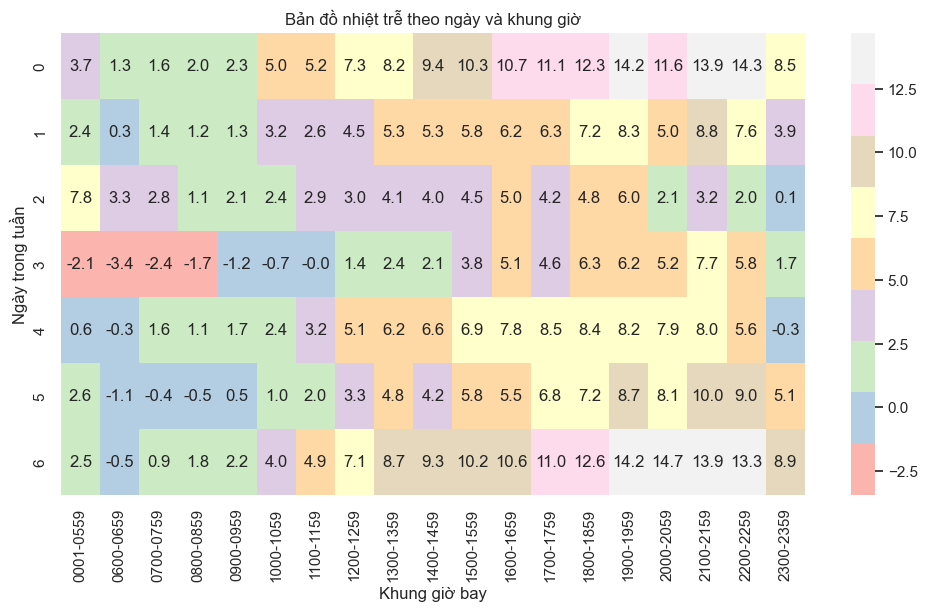

In [20]:
delay_by_hour = df.pivot_table(
    values='ARR_DELAY',
    index='DAY_OF_WEEK',
    columns='DEP_TIME_BLK',
    aggfunc='mean'
)

plt.figure(figsize=(12,6))
sns.heatmap(delay_by_hour, annot=True, fmt=".1f", cmap="Pastel1")

plt.title("Bản đồ nhiệt trễ theo ngày và khung giờ")
plt.xlabel("Khung giờ bay")
plt.ylabel("Ngày trong tuần")

plt.savefig("eda_chart/heatmap_thoi_gian.png")
plt.show()

3. Theo sân bay

In [27]:
delay_by_airport = df.groupby('ORIGIN')['ARR_DELAY'].mean().sort_values(ascending=False).head(10).reset_index()
delay_by_airport.columns = ['Sân bay', 'Trễ trung bình']
display(delay_by_airport)

,Sân bay,Trễ trung bình
0,MGW,64.739128
1,RIW,34.663460
2,DLG,29.826923
3,CNY,29.140350
4,HOB,27.074074
5,CKB,26.171232
6,IAG,25.282442
7,LNK,24.739550
8,COD,23.474684
9,SMX,23.156250


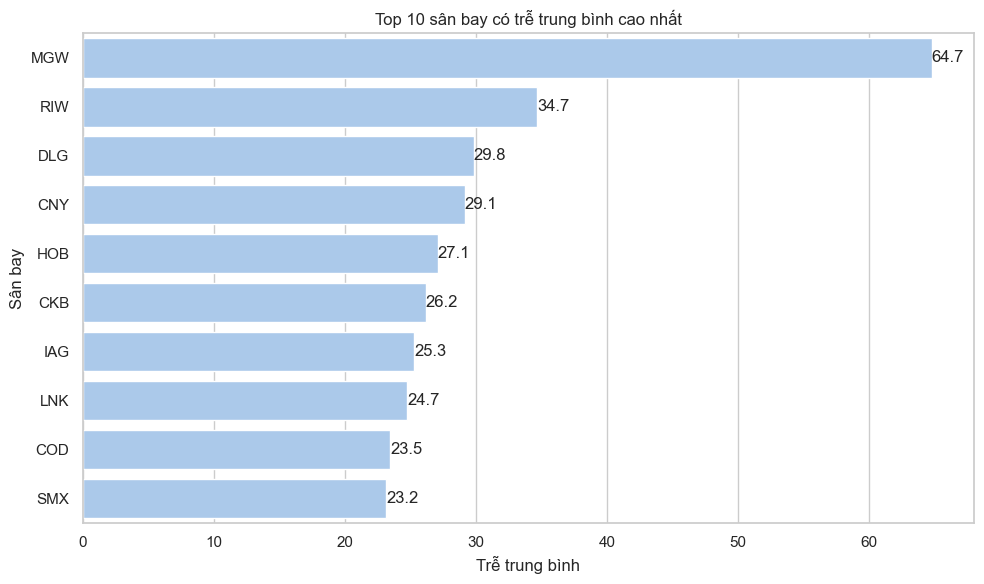

In [28]:
plt.figure(figsize=(10,6))
ax = sns.barplot(data=delay_by_airport, x='Trễ trung bình', y='Sân bay')

for i, row in delay_by_airport.iterrows():
    ax.text(row['Trễ trung bình'], i, f"{row['Trễ trung bình']:.1f}", va='center')

plt.title("Top 10 sân bay có trễ trung bình cao nhất")
plt.tight_layout()
plt.savefig("eda_chart/top10_san_bay_tre.png")
plt.show()

Nguyên nhân trễ theo sân bay

In [35]:
# nguyên nhân trễ theo sân bay
delay_by_airport_cause = df.groupby('ORIGIN')[delay_cols].mean()
delay_by_airport_cause.columns = [name_causes[col] for col in delay_by_airport_cause.columns]

delay_by_airport_cause = delay_by_airport_cause.reset_index()

df_melted = delay_by_airport_cause.melt(id_vars='ORIGIN', var_name='Nguyên nhân', value_name='Trễ trung bình')

display(df_melted)


,ORIGIN,Nguyên nhân,Trễ trung bình
0,ABE,Hãng hàng không,37.904545
1,ABI,Hãng hàng không,14.058333
2,ABQ,Hãng hàng không,22.487156
3,ABR,Hãng hàng không,84.780487
4,ABY,Hãng hàng không,68.313728
...,...,...,...
1845,XNA,Máy bay đến trễ,24.742586
1846,XWA,Máy bay đến trễ,14.865853
1847,YAK,Máy bay đến trễ,47.692307
1848,YKM,Máy bay đến trễ,14.076923


<Figure size 1200x600 with 0 Axes>

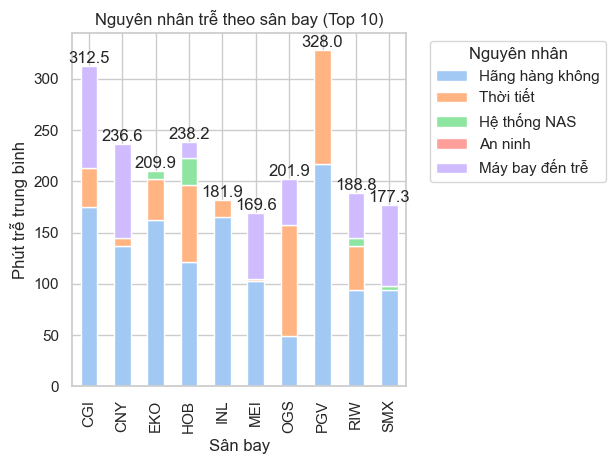

In [ ]:
top_airports = delay_by_airport_cause.set_index('ORIGIN') \
    .sum(axis=1) \
    .sort_values(ascending=False) \
    .head(10) \
    .index

data_plot = delay_by_airport_cause[
    delay_by_airport_cause['ORIGIN'].isin(top_airports)
].set_index('ORIGIN')

plt.figure(figsize=(12,6))

ax = data_plot.plot(
    kind='bar',
    stacked=True
)

# hiển thị tổng
for i, total in enumerate(data_plot.sum(axis=1)):
    ax.text(i, total, f"{total:.1f}", ha='center', va='bottom')

plt.title("Nguyên nhân trễ theo sân bay (Top 10)")
plt.xlabel("Sân bay")
plt.ylabel("Phút trễ trung bình")

plt.legend(title="Nguyên nhân", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.savefig("eda_chart/san_bay_nguyen_nhan_stacked.png")
plt.show()

4. Theo hãng bay

In [37]:
carrier_delay = (
    df.groupby('OP_UNIQUE_CARRIER')['ARR_DELAY']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

carrier_delay.columns = ['Hãng hàng không', 'Trễ trung bình']

display(carrier_delay)

,Hãng hàng không,Trễ trung bình
0,F9,12.008977
1,B6,11.444550
2,G4,10.326844
3,OH,8.490024
4,OO,7.778139
5,AA,7.205977
6,NK,6.933261
7,HA,6.554529
8,MQ,4.650379
9,UA,4.474905


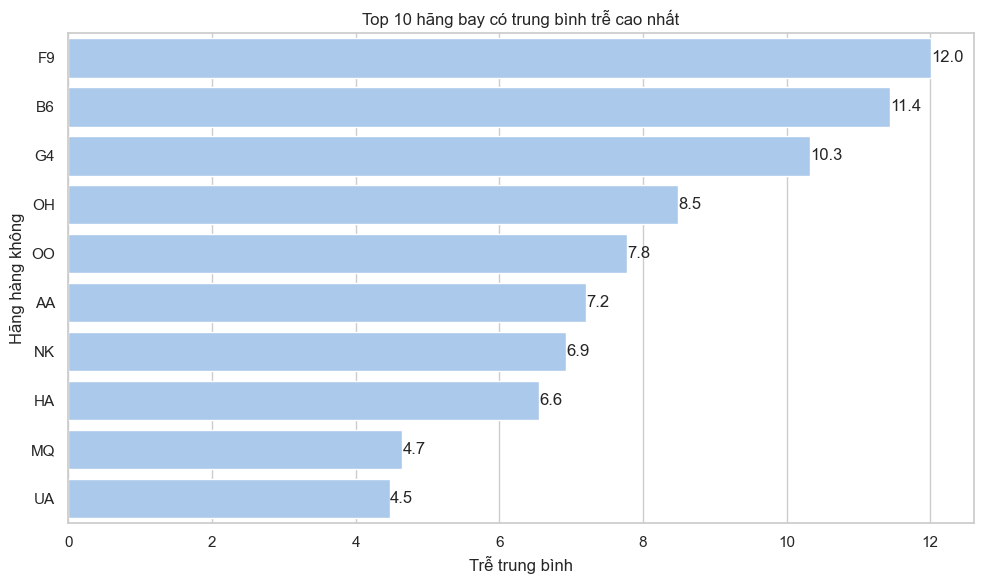

In [38]:
plt.figure(figsize=(10,6))
ax = sns.barplot(data=carrier_delay, x='Trễ trung bình', y='Hãng hàng không')

for i, row in carrier_delay.iterrows():
    ax.text(row['Trễ trung bình'], i, f"{row['Trễ trung bình']:.1f}", va='center')

plt.title("Top 10 hãng bay có trung bình trễ cao nhất")
plt.tight_layout()
plt.savefig("eda_chart/airline_delay.png")
plt.show()

5. Theo khoảng cách

In [39]:
dist = df.groupby('DISTANCE_GROUP')['ARR_DELAY'].mean().reset_index()
dist.columns = ['Khoảng cách', 'Trễ trung bình']
display(dist)

,Khoảng cách,Trễ trung bình
0,1,5.351814
1,2,4.277374
2,3,5.093953
3,4,5.320217
4,5,6.820704
5,6,3.294399
6,7,4.766294
7,8,1.641391
8,9,1.063655
9,10,-0.832409


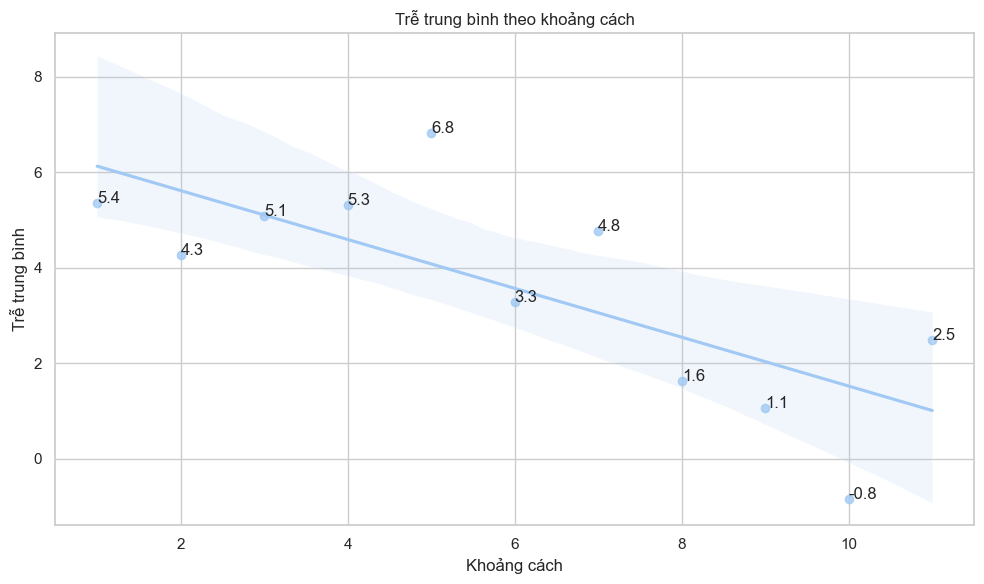

In [40]:
plt.figure(figsize=(10,6))
sns.regplot(x='Khoảng cách', y='Trễ trung bình', data=dist)

for i, row in dist.iterrows():
    plt.text(row['Khoảng cách'], row['Trễ trung bình'], f"{row['Trễ trung bình']:.1f}")

plt.title("Trễ trung bình theo khoảng cách")
plt.tight_layout()
plt.savefig("eda_chart/tre_theo_khoang_cach.png")
plt.show()

6. Mối quan hệ giữa các nguyên nhân

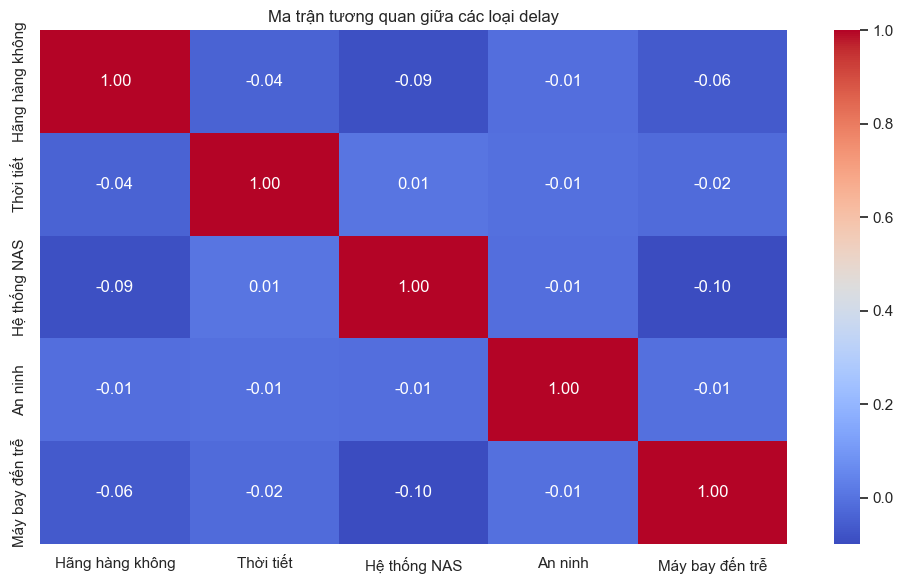

In [47]:
plt.figure(figsize=(10,6))

corr = df[delay_cols].corr()

corr = corr.rename(index=name_causes, columns=name_causes)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Ma trận tương quan giữa các loại delay")
plt.tight_layout()
plt.savefig("eda_chart/tuong_quan_delay.png")
plt.show()

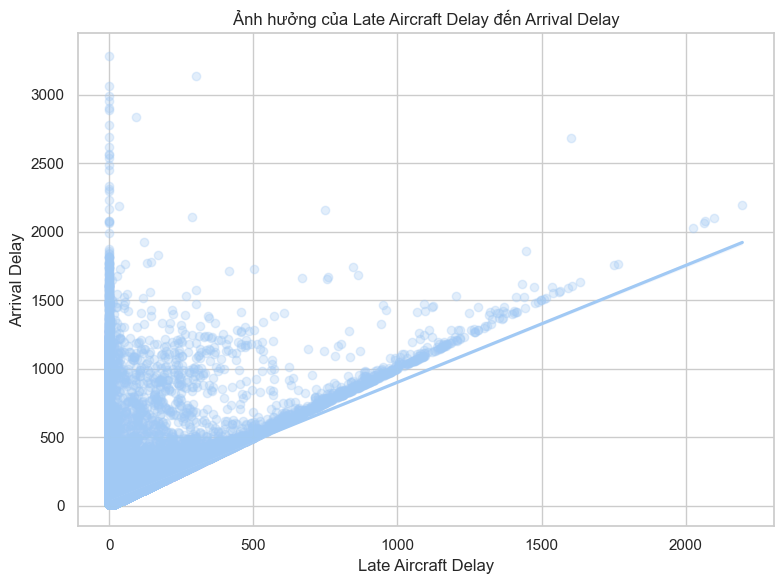

In [48]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x='LATE_AIRCRAFT_DELAY',
    y='ARR_DELAY',
    scatter_kws={'alpha':0.3}
)

plt.title("Ảnh hưởng của Late Aircraft Delay đến Arrival Delay")
plt.xlabel("Late Aircraft Delay")
plt.ylabel("Arrival Delay")

plt.tight_layout()
plt.savefig("eda_chart/late_aircraft_vs_arrival.png")
plt.show()

7. Phân tích chuyến bay trễ nghiêm trọng

In [49]:
df_severe = df[df['ARR_DELAY'] > 60]   # trễ > 60 phút
ty_le = len(df_severe) / len(df)

print(f"Tỷ lệ chuyến bay trễ nghiêm trọng: {ty_le:.2%}")

Tỷ lệ chuyến bay trễ nghiêm trọng: 6.37%


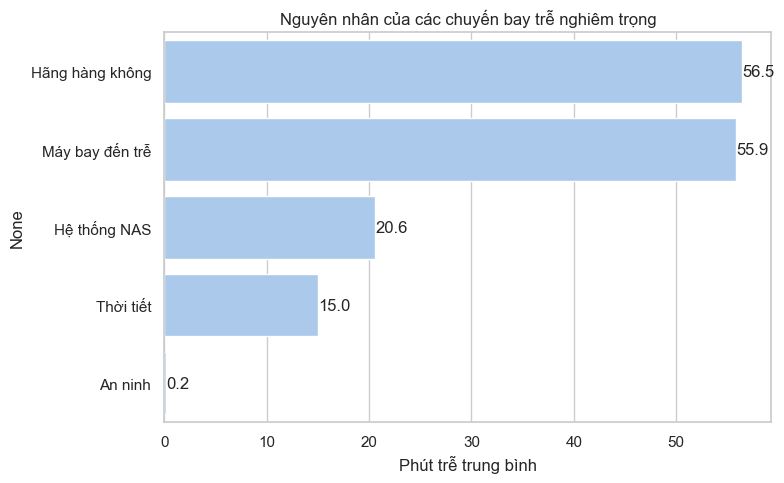

In [50]:
severe_cause = df_severe[delay_cols].mean()
severe_cause.index = [name_causes[col] for col in severe_cause.index]

severe_cause = severe_cause.sort_values(ascending=False)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=severe_cause.values,
    y=severe_cause.index
)

for i, v in enumerate(severe_cause.values):
    ax.text(v, i, f"{v:.1f}", va='center')

plt.title("Nguyên nhân của các chuyến bay trễ nghiêm trọng")
plt.xlabel("Phút trễ trung bình")

plt.tight_layout()
#plt.savefig("eda_chart/nguyen_nhan_tre_nghiem_trong.png")
plt.show()

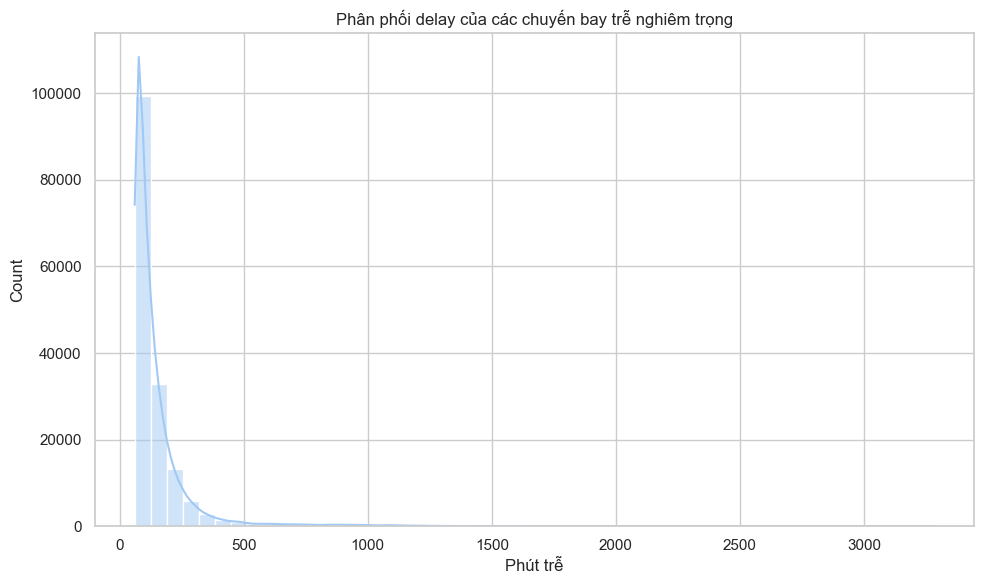

In [51]:
plt.figure(figsize=(10,6))

sns.histplot(
    df_severe['ARR_DELAY'],
    kde=True,
    bins=50
)

plt.title("Phân phối delay của các chuyến bay trễ nghiêm trọng")
plt.xlabel("Phút trễ")

plt.tight_layout()
plt.savefig("eda_chart/phan_phoi_tre_nghiem_trong.png")
plt.show()

Nguyên nhân trễ chính của từng chuyến bay

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12020\2947934934.py:1: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  df['Nguyên nhân chính'] = df[delay_cols].idxmax(axis=1)


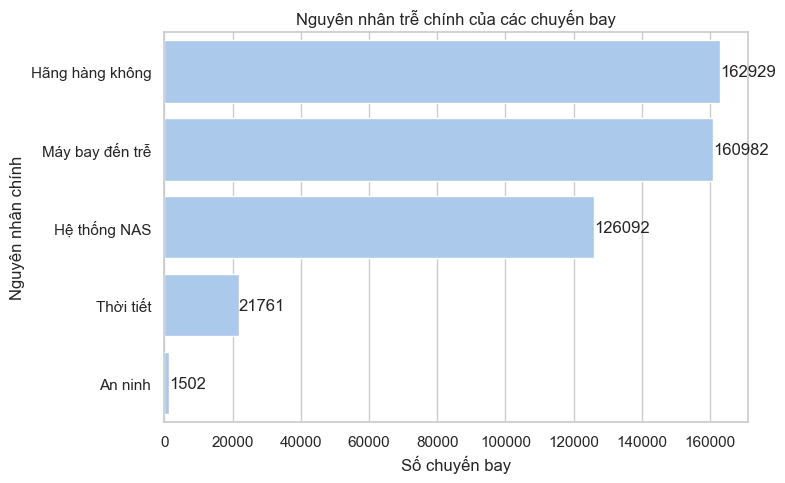

In [52]:
df['Nguyên nhân chính'] = df[delay_cols].idxmax(axis=1)
df['Nguyên nhân chính'] = df['Nguyên nhân chính'].map(name_causes)

main_cause_count = df['Nguyên nhân chính'].value_counts()

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=main_cause_count.values,
    y=main_cause_count.index
)

for i, v in enumerate(main_cause_count.values):
    ax.text(v, i, str(v), va='center')

plt.title("Nguyên nhân trễ chính của các chuyến bay")
plt.xlabel("Số chuyến bay")

plt.tight_layout()
plt.savefig("eda_chart/nguyen_nhan_chinh.png")
plt.show()